# Proceso de Machine Learning

## Árbol de decisión

La mejor métrica es: 
0.7687296416938111
El mejor dataset es: 
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              0      162             76             56      100  53.2   
1              2       87              0             23        0  28.9   
2              0      137             68             14      148  24.8   
3             10      115              0              0        0  35.3   
4              0      104             64             37       64  33.6   
..           ...      ...            ...            ...      ...   ...   
609            1      133            102             28      140  32.8   
610            4      129             60             12      231  27.5   
611            3      116             74             15      105  26.3   
612            1       88             30             42       99  55.0   
613            5       96             74             18       67  33.6   

     DiabetesPedigreeFunction  Age  
0          

[Text(0.5, 0.875, 'x[1] <= 154.5\ngini = 0.449\nsamples = 614\nvalue = [405, 209]'),
 Text(0.25, 0.625, 'x[5] <= 26.35\ngini = 0.372\nsamples = 511\nvalue = [385, 126]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[7] <= 53.5\ngini = 0.032\nsamples = 122\nvalue = [120, 2]'),
 Text(0.0625, 0.125, 'gini = 0.0\nsamples = 111\nvalue = [111, 0]'),
 Text(0.1875, 0.125, 'gini = 0.298\nsamples = 11\nvalue = [9, 2]'),
 Text(0.375, 0.375, 'x[7] <= 30.5\ngini = 0.434\nsamples = 389\nvalue = [265, 124]'),
 Text(0.3125, 0.125, 'gini = 0.318\nsamples = 217\nvalue = [174, 43]'),
 Text(0.4375, 0.125, 'gini = 0.498\nsamples = 172\nvalue = [91.0, 81.0]'),
 Text(0.75, 0.625, 'x[7] <= 62.5\ngini = 0.313\nsamples = 103\nvalue = [20, 83]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[4] <= 544.0\ngini = 0.287\nsamples = 98\nvalue = [17, 81]'),
 Text(0.5625, 0.125, 'gini = 0.256\nsamples = 93\nvalue = [14, 79]'),
 Text(0.6875, 0.125, 'gini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.875

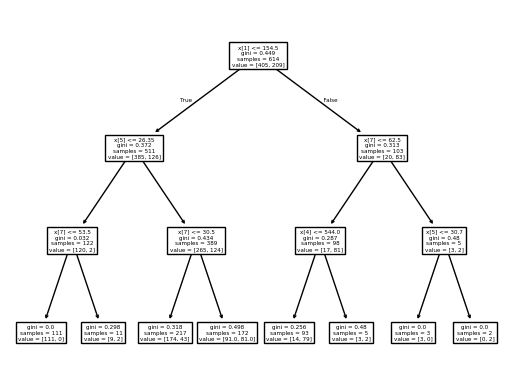

In [ ]:
import pandas as pd

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
from sklearn import tree

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV


X_train_CON_outliers = pd.read_excel("../data/processed/X_train_CON_outliers.xlsx")

X_train_SIN_outliers = pd.read_excel("../data/processed/X_train_SIN_outliers.xlsx")

y_train = pd.read_excel("../data/processed/y_train.xlsx")

datasets = [X_train_CON_outliers,
    X_train_SIN_outliers
    ]
models = []
metrics = []


for dataset in datasets:

    model = DecisionTreeClassifier(max_depth=3, random_state=10) #ML class
    model.fit(dataset, y_train)
    y_pred = model.predict(dataset)
    metric = accuracy_score(y_train, y_pred)
    metrics.append(metric)
    models.append(model)


best_metric = max(metrics)
best_index = metrics.index(best_metric)
print(f"La mejor métrica es: \n{best_metric}")
print(f"El mejor dataset es: \n{datasets[best_index]}")

model = DecisionTreeClassifier(max_depth=3, random_state=10) #ML class
model.fit(datasets[best_index], y_train)


plot_tree(model)

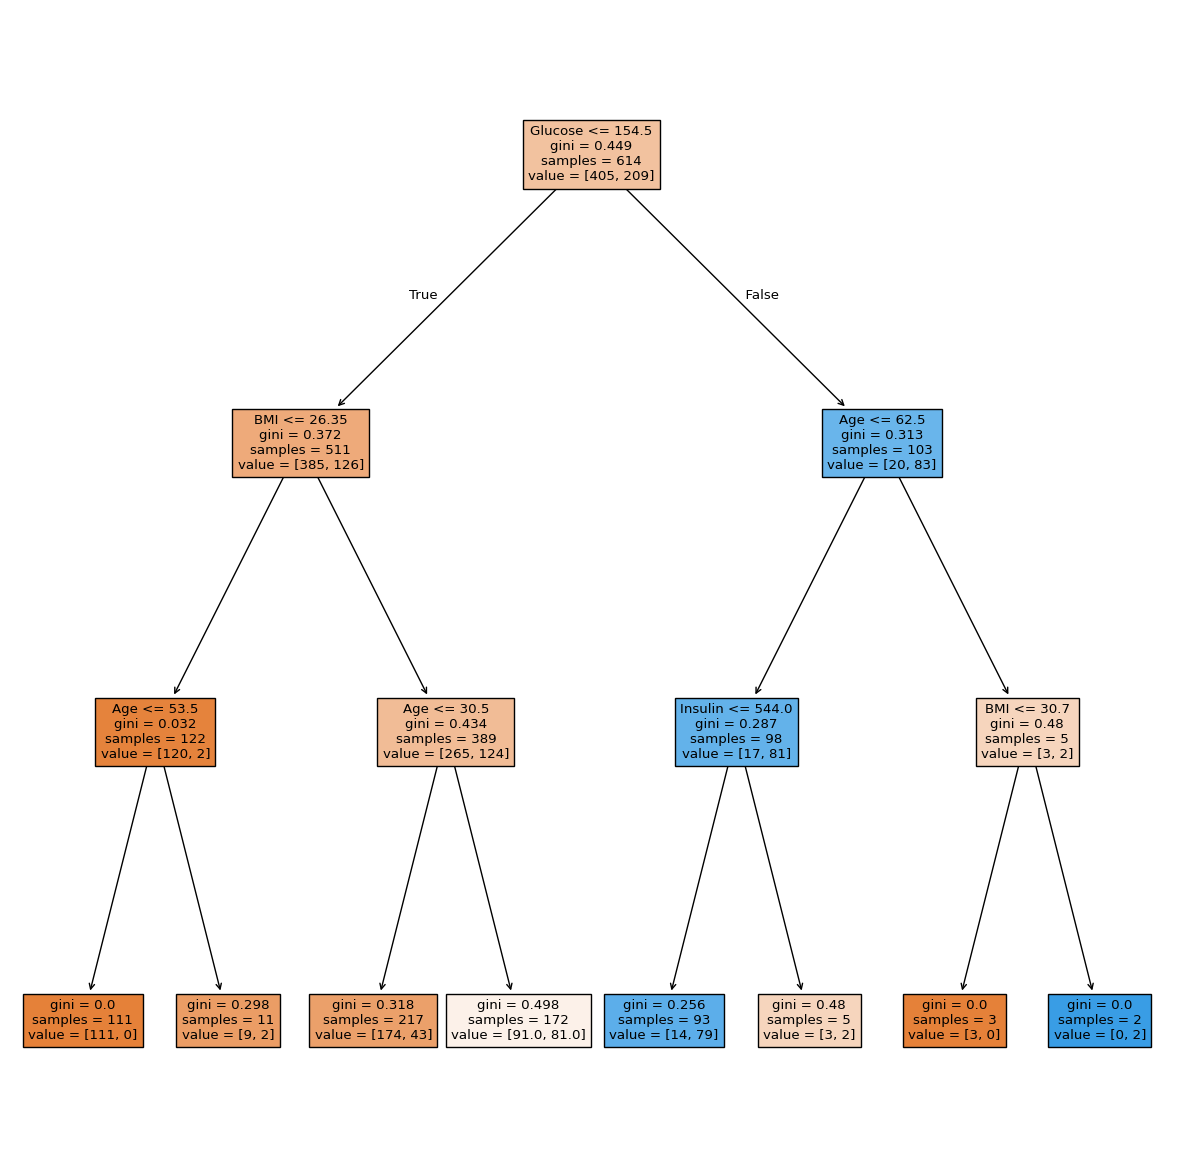

In [23]:
fig = plt.figure(figsize=(15,15))

tree.plot_tree(model, feature_names = list(datasets[best_index].columns), filled = True)

plt.show()

## Optimizacion de hiperparámetros

In [24]:
params= {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3, 5, 8],
    "min_samples_split": [2, 4, 6], 
    "min_samples_leaf": [1, 3, 5], 
    "max_features": [None, "sqrt", "log2"], 
    "min_impurity_decrease": [0.0, 0.1, 0.5], 
    "class_weight": [None, "balanced"],
    "ccp_alpha": [0.0, 0.1, 0.01]
}

### Grid search

In [25]:
grid = GridSearchCV(DecisionTreeClassifier(random_state=10), params, scoring="accuracy", cv=5, n_jobs = -1)
grid.fit(datasets[best_index], y_train)
print(grid.best_params_)
best_model = grid.best_estimator_
print("El mejor estimador es: ", best_model)
print("La mejor puntuación es: ", grid.best_score_)

{'ccp_alpha': 0.01, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 8, 'max_features': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2}
El mejor estimador es:  DecisionTreeClassifier(ccp_alpha=0.01, criterion='entropy', max_depth=8,
                       random_state=10)
La mejor puntuación es:  0.7557377049180328


### Random search

In [26]:
grid = RandomizedSearchCV(DecisionTreeClassifier(random_state=10), params, scoring="accuracy", n_iter = 30, cv=5, n_jobs = -1)
grid.fit(datasets[best_index], y_train)
print(grid.best_params_)
best_model = grid.best_estimator_
print(best_model)
print("El mejor estimador es: ", best_model)
print("La mejor puntuación es: ", grid.best_score_)

{'min_samples_split': 4, 'min_samples_leaf': 5, 'min_impurity_decrease': 0.0, 'max_features': None, 'max_depth': 8, 'criterion': 'entropy', 'class_weight': 'balanced', 'ccp_alpha': 0.01}
DecisionTreeClassifier(ccp_alpha=0.01, class_weight='balanced',
                       criterion='entropy', max_depth=8, min_samples_leaf=5,
                       min_samples_split=4, random_state=10)
El mejor estimador es:  DecisionTreeClassifier(ccp_alpha=0.01, class_weight='balanced',
                       criterion='entropy', max_depth=8, min_samples_leaf=5,
                       min_samples_split=4, random_state=10)
La mejor puntuación es:  0.7280287884846062


## Métricas finales

Volvemos a entrenar el modelo con el mejor dataset de x_train y x_test

In [27]:
X_test_CON_outliers = pd.read_excel("../data/processed/X_test_CON_outliers.xlsx")
X_test_SIN_outliers = pd.read_excel("../data/processed/X_test_SIN_outliers.xlsx")


y_test = pd.read_excel("../data/processed/y_test.xlsx")

datasets_test = [X_test_CON_outliers,
    X_test_SIN_outliers
    ]


model_f = DecisionTreeClassifier(ccp_alpha=0.01, criterion='entropy', max_depth=8,
                       random_state=10)
model_f.fit(datasets[best_index], y_train)

y_pred = model_f.predict(datasets[best_index])
metric_train = accuracy_score(y_train, y_pred)


y_pred = model_f.predict(datasets_test[best_index])
metric_test = accuracy_score(y_test, y_pred)


print(f"La mejor métrica de nuestros datasets x_train son: {metric_train} y los x_test son: {metric_test}")

La mejor métrica de nuestros datasets x_train son: 0.7947882736156352 y los x_test son: 0.7662337662337663


[Text(0.4791666666666667, 0.9375, 'x[1] <= 154.5\nentropy = 0.925\nsamples = 614\nvalue = [405, 209]'),
 Text(0.3958333333333333, 0.8125, 'x[5] <= 26.35\nentropy = 0.806\nsamples = 511\nvalue = [385, 126]'),
 Text(0.4375, 0.875, 'True  '),
 Text(0.16666666666666666, 0.6875, 'x[7] <= 53.5\nentropy = 0.121\nsamples = 122\nvalue = [120, 2]'),
 Text(0.08333333333333333, 0.5625, 'entropy = 0.0\nsamples = 111\nvalue = [111, 0]'),
 Text(0.25, 0.5625, 'entropy = 0.684\nsamples = 11\nvalue = [9, 2]'),
 Text(0.625, 0.6875, 'x[7] <= 30.5\nentropy = 0.903\nsamples = 389\nvalue = [265, 124]'),
 Text(0.4166666666666667, 0.5625, 'x[1] <= 118.5\nentropy = 0.718\nsamples = 217\nvalue = [174, 43]'),
 Text(0.25, 0.4375, 'x[5] <= 45.4\nentropy = 0.528\nsamples = 134\nvalue = [118, 16]'),
 Text(0.16666666666666666, 0.3125, 'x[6] <= 0.501\nentropy = 0.488\nsamples = 132\nvalue = [118, 14]'),
 Text(0.08333333333333333, 0.1875, 'entropy = 0.302\nsamples = 93\nvalue = [88, 5]'),
 Text(0.25, 0.1875, 'x[5] <= 32

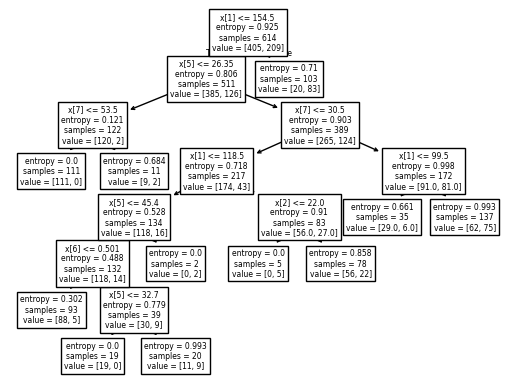

In [28]:
plot_tree(model_f)